# Portfolio Performance & Risk Analyzer

Historical performance and risk analysis of an equal-weight portfolio of five NSE large-cap stocks.

**How to use this notebook.** Run `python main.py` first. It downloads the data from Yahoo Finance and saves it to `data/prices_raw.csv`. This notebook then loads that same file, so every number here matches the PDF report. If the file is missing, the notebook downloads the data itself.

The core calculations are written out step by step below, rather than hidden inside functions, so each one can be read and explained. The last section checks that these step-by-step numbers agree with the project code in `analytics.py`.

## 1. Project Objective

Measure how an equally weighted portfolio of Reliance Industries, TCS, HDFC Bank, Infosys and ICICI Bank performed over the most recent two years, how much risk it carried, and where that risk came from.

The analysis is descriptive. It explains what happened; it does not forecast prices or recommend trades.

## 2. Business / Finance Problem

A portfolio analytics team answers three questions for every portfolio it reports on:

1. **Performance:** did the portfolio make money, and how did that compare with the market (NIFTY 50)?
2. **Risk-adjusted performance:** was the return worth the risk taken?
3. **Diversification:** is the portfolio as diversified as its five holdings suggest, and which holdings drive its risk?

Raw return answers only the first question. Volatility, drawdown, the Sharpe Ratio, correlation and risk contribution answer the other two.

## 3. Dataset and Data Source

| Item | Detail |
|---|---|
| Source | Yahoo Finance, via the open-source `yfinance` package |
| Securities | RELIANCE.NS, TCS.NS, HDFCBANK.NS, INFY.NS, ICICIBANK.NS, and ^NSEI (NIFTY 50) as benchmark |
| Field | Daily **adjusted** close (adjusted for dividends and splits) |
| Period | Most recent 2 years, ending on the run date (see `config.py`) |
| Risk-free rate | 91-day T-Bill cut-off yield, RBI auction of 2 Sep 2026: 5.26% ([source](https://mutualfund.adityabirlacapital.com/-/media/knowledgecenter/pdf/daily-fixed-income-tracker-03-sep-2026.pdf)) |

Adjusted prices matter: on a dividend date the raw price drops even though the shareholder lost nothing. Adjusted prices remove that artificial drop.

In [1]:
import os
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

import config
import analytics
import charts
from analytics import PORTFOLIO_NAME

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

if os.path.exists(config.PRICES_FILE):
    raw = analytics.load_prices()
    print("Loaded saved prices from", config.PRICES_FILE)
    print(json.dumps(analytics.load_download_info(), indent=2))
else:
    os.makedirs(config.DATA_DIR, exist_ok=True)
    start, end = config.resolve_dates()
    raw = analytics.fetch_prices(start, end)
    print("Downloaded prices from Yahoo Finance:", start, "to", end)

raw.tail()

Loaded saved prices from data/prices_raw.csv
{
  "source": "Yahoo Finance via the yfinance Python package",
  "yfinance_version": "1.7.0",
  "tickers": [
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "INFY.NS",
    "ICICIBANK.NS",
    "^NSEI"
  ],
  "requested_start": "2024-10-05",
  "requested_end": "2026-10-05",
  "downloaded_at": "2026-10-06T09:32:01",
  "price_field": "Close with auto_adjust=True (dividend and split adjusted)"
}


,Reliance Industries,TCS,HDFC Bank,Infosys,ICICI Bank,NIFTY 50
Date,,,,,,
2026-09-29,"1,182.0000","2,032.4000",722.7000,"1,015.4000","1,292.2000","22,716.1992"
2026-09-30,"1,187.0000","2,050.6001",708.7000,994.1000,"1,321.7000","22,620.4492"
2026-10-01,"1,167.7000","2,075.0000",721.2000,"1,035.0000","1,310.6000","22,421.9492"
2026-10-02,"1,167.7000","2,075.0000",721.2000,"1,035.0000","1,310.6000",NaN
2026-10-05,"1,186.4000","2,114.3999",704.8000,"1,020.5000","1,332.0000","22,555.7500"


## 4. Methodology

| Step | Method |
|---|---|
| Daily return | $r_t = P_t / P_{t-1} - 1$ |
| Portfolio return | $r_{p,t} = \sum_i w_i \, r_{i,t}$ with $w_i = 20\%$ (weights reset daily) |
| Cumulative return | $\prod_t (1 + r_t) - 1$ |
| Annualised return (CAGR) | $(1 + \text{cumulative})^{252/N} - 1$ |
| Annualised volatility | $\sigma_{daily} \times \sqrt{252}$ |
| Sharpe Ratio | $\dfrac{\text{mean}(r_t - r_f^{daily})}{\sigma_{daily}} \times \sqrt{252}$ |
| Maximum drawdown | $\min_t \left( V_t / \max_{s \le t} V_s - 1 \right)$ |
| Beta | $\text{cov}(r, r_m) / \text{var}(r_m)$ |
| Risk contribution | $RC_i = w_i (\Sigma w)_i / \sigma_p$, which sums to $\sigma_p$ |

**Assumptions:** 252 trading days per year; risk-free rate 5.26% a year; constant 20% weights (daily rebalancing), with buy-and-hold shown as a check; no transaction costs or taxes; sample standard deviation.

## 5. Data Cleaning

Steps: sort by date, remove duplicate dates, drop dates with no prices at all, fill short gaps (up to 2 days) with the last known price, drop any date that still has a gap, and confirm every price is positive. The result is a table in which every security has a price on exactly the same dates.

In [2]:
prices, clean_log = analytics.clean_prices(raw)
print(json.dumps(clean_log, indent=2))

stock_names = list(config.WEIGHTS)
has_bench = config.BENCHMARK_NAME in prices.columns
stock_prices = prices[stock_names]
print("\nMissing values after cleaning:", int(prices.isna().sum().sum()))
prices.describe().T[["count", "min", "max"]]

{
  "rows_raw": 500,
  "duplicate_dates_removed": 0,
  "empty_dates_removed": 0,
  "missing_values_before_fill": {
    "Reliance Industries": 0,
    "TCS": 0,
    "HDFC Bank": 0,
    "Infosys": 0,
    "ICICI Bank": 0,
    "NIFTY 50": 6
  },
  "values_forward_filled": 6,
  "incomplete_dates_removed": 0,
  "rows_clean": 500,
  "first_date": "2024-10-07",
  "last_date": "2026-10-05"
}

Missing values after cleaning: 0


,count,min,max
Reliance Industries,500.0000,"1,151.9518","1,584.9718"
TCS,500.0000,"1,971.7888","4,166.6646"
HDFC Bank,500.0000,687.1000,996.4198
Infosys,500.0000,985.3000,"1,901.0829"
ICICI Bank,500.0000,"1,177.0677","1,464.8524"
NIFTY 50,500.0000,"22,082.6504","26,328.5508"


## 6. Return Calculation

`pct_change()` computes $P_t / P_{t-1} - 1$ for every column. The first row has no previous price, so it is dropped.

In [3]:
stock_r = stock_prices.pct_change().iloc[1:]
bench_r = prices[config.BENCHMARK_NAME].pct_change().iloc[1:] if has_bench else None

print("Trading days with a return:", len(stock_r))
stock_r.head()

Trading days with a return: 499


,Reliance Industries,TCS,HDFC Bank,Infosys,ICICI Bank
Date,,,,,
2024-10-08,0.0194,-0.0046,0.0206,0.0074,0.0022
2024-10-09,-0.0163,-0.0001,-0.0108,0.0022,0.0061
2024-10-10,-0.0026,-0.0060,0.0179,-0.0173,-0.0005
2024-10-11,0.0008,-0.0185,-0.0069,0.0084,-0.0165
2024-10-14,0.0003,-0.0030,0.0225,0.0123,0.0072


## 7. Portfolio Construction

Equal weights: 20% in each stock. Multiplying each day's stock returns by the weights and adding them up gives the portfolio's daily return. Holding the weights at 20% every day assumes daily rebalancing.

In [4]:
w = pd.Series(config.WEIGHTS)[stock_names]
print(w, "\nSum of weights:", w.sum())

port_r = (stock_r * w).sum(axis=1).rename(PORTFOLIO_NAME)

# Sector exposure (for the diversification discussion later)
print("\nSector weights:")
print(w.groupby(pd.Series(config.SECTORS)).sum().sort_values(ascending=False))

Reliance Industries   0.2000
TCS                   0.2000
HDFC Bank             0.2000
Infosys               0.2000
ICICI Bank            0.2000
dtype: float64 
Sum of weights: 1.0

Sector weights:
Banking                  0.4000
Information Technology   0.4000
Energy & Conglomerate    0.2000
dtype: float64


## 8. Performance Analysis

Cumulative return compounds the daily returns. CAGR converts that total into a constant yearly rate, which makes periods of different length comparable.

In [5]:
TD = config.TRADING_DAYS
all_r = stock_r.copy()
all_r[PORTFOLIO_NAME] = port_r
if has_bench:
    all_r[config.BENCHMARK_NAME] = bench_r

cumulative = (1 + all_r).prod() - 1
cagr = (1 + cumulative) ** (TD / len(all_r)) - 1

performance = pd.DataFrame({"Cumulative return": cumulative, "CAGR": cagr})
performance.style.format("{:.2%}")

,Cumulative return,CAGR
Reliance Industries,-12.70%,-6.63%
TCS,-46.74%,-27.25%
HDFC Bank,-10.23%,-5.30%
Infosys,-43.87%,-25.30%
ICICI Bank,9.70%,4.79%
Equal-Weight Portfolio,-21.61%,-11.57%
NIFTY 50,-9.03%,-4.67%


In [6]:
# Buy-and-hold check: invest 20% in each stock on day one and never rebalance.
bh_value = (stock_prices / stock_prices.iloc[0] * w).sum(axis=1)
print(f"Rebalanced portfolio total return : {cumulative[PORTFOLIO_NAME]:.2%}")
print(f"Buy-and-hold portfolio total return: {bh_value.iloc[-1] - 1:.2%}")

Rebalanced portfolio total return : -21.61%
Buy-and-hold portfolio total return: -20.77%


## 9. Risk Analysis

* **Volatility:** standard deviation of daily returns, scaled by $\sqrt{252}$ because variance grows in proportion to time.
* **Sharpe Ratio:** average daily return above the daily risk-free rate, divided by daily volatility, then scaled by $\sqrt{252}$.
* **Maximum drawdown:** the largest fall from a previous peak in the value of Rs 1 invested.
* **Beta:** how much each security moved, on average, for a 1% move in the NIFTY 50.

In [7]:
rf = config.RISK_FREE_RATE
rf_daily = (1 + rf) ** (1 / TD) - 1

volatility = all_r.std() * np.sqrt(TD)
sharpe = (all_r - rf_daily).mean() / all_r.std() * np.sqrt(TD)

wealth = (1 + all_r).cumprod()
wealth = pd.concat([pd.DataFrame(1.0, index=[prices.index[0]], columns=all_r.columns), wealth])
drawdown = wealth / wealth.cummax() - 1
max_dd = drawdown.min()

beta = (all_r.apply(lambda col: col.cov(bench_r)) / bench_r.var()) if has_bench else np.nan

risk = pd.DataFrame({"Volatility": volatility, "Sharpe": sharpe,
                     "Max drawdown": max_dd, "Beta": beta})
print(f"Risk-free rate {rf:.2%} a year = {rf_daily:.6%} a day")
risk.style.format({"Volatility": "{:.2%}", "Sharpe": "{:.2f}",
                   "Max drawdown": "{:.2%}", "Beta": "{:.2f}"})

Risk-free rate 5.26% a year = 0.020345% a day


,Volatility,Sharpe,Max drawdown,Beta
Reliance Industries,20.61%,-0.48,-26.33%,1.04
TCS,24.83%,-1.36,-52.68%,0.84
HDFC Bank,19.68%,-0.44,-31.04%,1.07
Infosys,27.98%,-1.09,-48.17%,0.90
ICICI Bank,18.38%,0.07,-18.37%,0.90
Equal-Weight Portfolio,15.03%,-1.08,-26.52%,0.95
NIFTY 50,12.98%,-0.70,-15.18%,1.00


In [8]:
# When did the portfolio's worst drawdown happen?
trough = drawdown[PORTFOLIO_NAME].idxmin()
peak = wealth[PORTFOLIO_NAME].loc[:trough].idxmax()
print(f"Peak: {peak.date()}  Trough: {trough.date()}  Drawdown: {max_dd[PORTFOLIO_NAME]:.2%}")

# Sharpe sensitivity: does the conclusion depend on the risk-free rate?
pd.DataFrame({f"rf={x:.0%}": (all_r - ((1 + x) ** (1 / TD) - 1)).mean() / all_r.std() * np.sqrt(TD)
              for x in config.RF_SENSITIVITY}).style.format("{:.2f}")

Peak: 2024-12-13  Trough: 2026-09-30  Drawdown: -26.52%


,rf=0%,rf=5%,rf=6%,rf=7%
Reliance Industries,-0.23,-0.47,-0.51,-0.56
TCS,-1.16,-1.35,-1.39,-1.43
HDFC Bank,-0.18,-0.43,-0.47,-0.52
Infosys,-0.90,-1.08,-1.11,-1.14
ICICI Bank,0.35,0.08,0.03,-0.02
Equal-Weight Portfolio,-0.74,-1.07,-1.13,-1.19
NIFTY 50,-0.30,-0.68,-0.75,-0.83


## 10. Correlation / Diversification Analysis

Correlation runs from -1 to +1. The lower the correlation between holdings, the more their ups and downs cancel out, and the lower portfolio volatility is compared with the average volatility of the holdings.

**Risk contribution** splits portfolio volatility into the part caused by each stock, using the covariance matrix $\Sigma$. If a stock's share of risk is above its 20% weight, it adds more risk than its capital allocation suggests.

In [9]:
corr = stock_r.corr()
display(corr.style.format("{:.2f}").background_gradient(cmap="Blues", vmin=0, vmax=1))

cov = stock_r.cov() * TD                          # annualised covariance matrix
port_vol = np.sqrt(w @ cov @ w)                   # sqrt(w' Sigma w)
weighted_avg_vol = (w * stock_r.std() * np.sqrt(TD)).sum()

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print(f"Portfolio volatility (w'Σw)         : {port_vol:.2%}")
print(f"Weighted average stock volatility   : {weighted_avg_vol:.2%}")
print(f"Volatility removed by diversifying  : {1 - port_vol / weighted_avg_vol:.2%}")
print(f"Diversification ratio               : {weighted_avg_vol / port_vol:.2f}")
print(f"Average pairwise correlation        : {pairs.mean():.2f}")
print(f"Most correlated pair                : {pairs.idxmax()} {pairs.max():.2f}")
print(f"Least correlated pair               : {pairs.idxmin()} {pairs.min():.2f}")

,Reliance Industries,TCS,HDFC Bank,Infosys,ICICI Bank
Reliance Industries,1.00,0.25,0.39,0.20,0.27
TCS,0.25,1.00,0.18,0.74,0.17
HDFC Bank,0.39,0.18,1.00,0.20,0.50
Infosys,0.20,0.74,0.20,1.00,0.13
ICICI Bank,0.27,0.17,0.50,0.13,1.00


Portfolio volatility (w'Σw)         : 15.03%
Weighted average stock volatility   : 22.30%
Volatility removed by diversifying  : 32.58%
Diversification ratio               : 1.48
Average pairwise correlation        : 0.30
Most correlated pair                : ('TCS', 'Infosys') 0.74
Least correlated pair               : ('Infosys', 'ICICI Bank') 0.13


In [10]:
marginal = cov @ w / port_vol
contribution = w * marginal
risk_contrib = pd.DataFrame({
    "Weight": w,
    "Share of risk": contribution / port_vol,
    "Return contribution (annual)": w * stock_r.mean() * TD,
})
risk_contrib["Risk share - weight"] = risk_contrib["Share of risk"] - risk_contrib["Weight"]
print("Shares of risk add up to:", round(risk_contrib["Share of risk"].sum(), 6))
risk_contrib.style.format("{:.2%}")

Shares of risk add up to: 1.0


,Weight,Share of risk,Return contribution (annual),Risk share - weight
Reliance Industries,20.00%,16.43%,-0.95%,-3.57%
TCS,20.00%,25.30%,-5.74%,5.30%
HDFC Bank,20.00%,16.45%,-0.70%,-3.55%
Infosys,20.00%,28.18%,-5.05%,8.18%
ICICI Bank,20.00%,13.64%,1.27%,-6.36%


## 11. Visualizations

The charts are drawn by `charts.py` (the same files used in the PDF report).

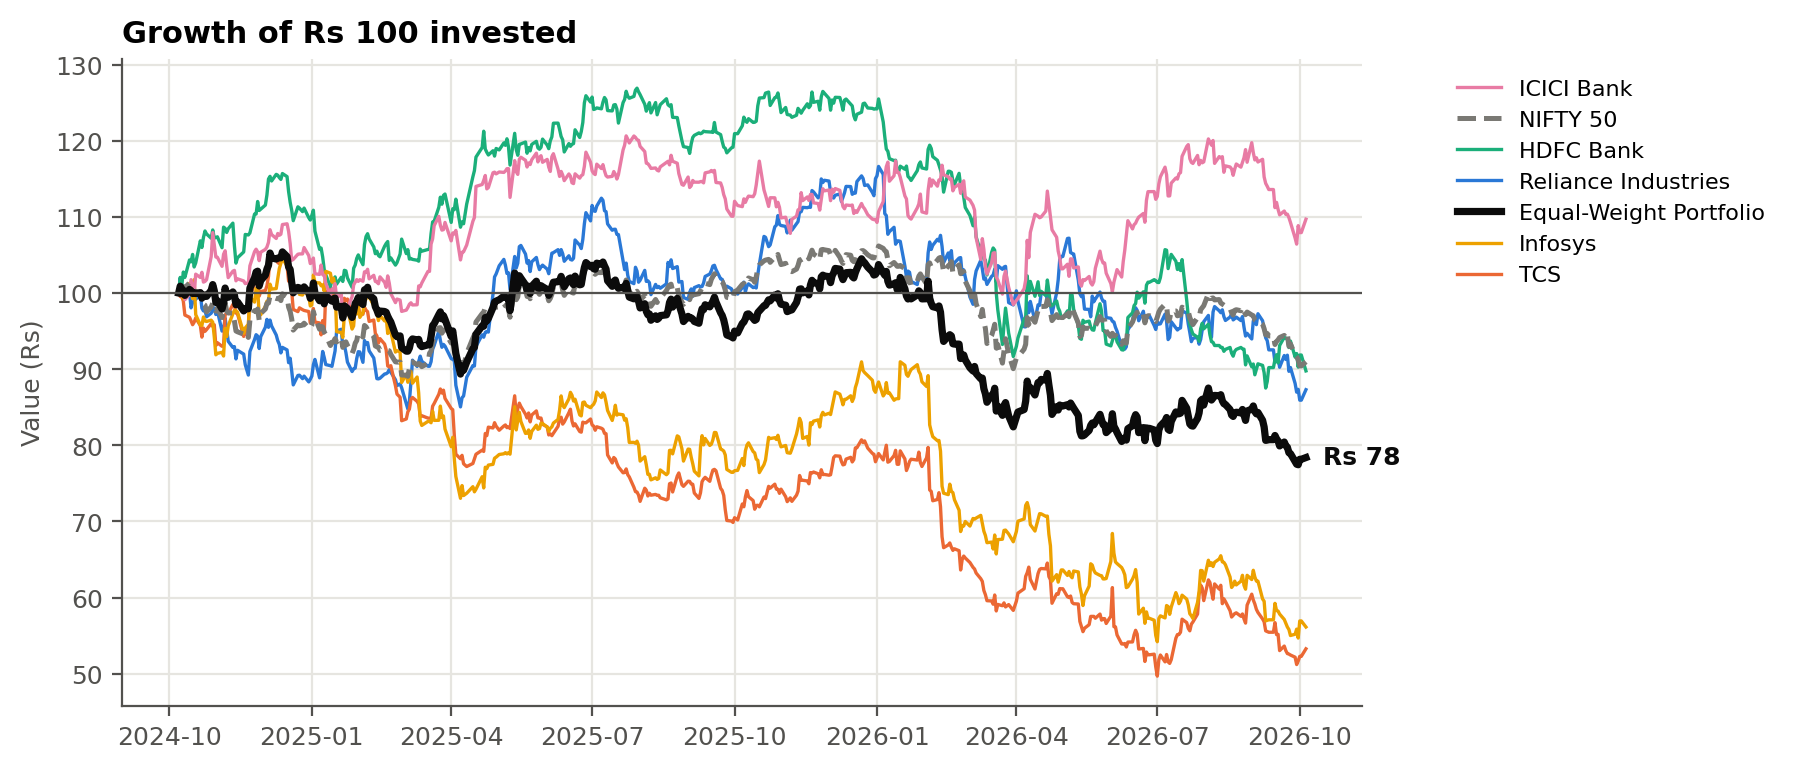

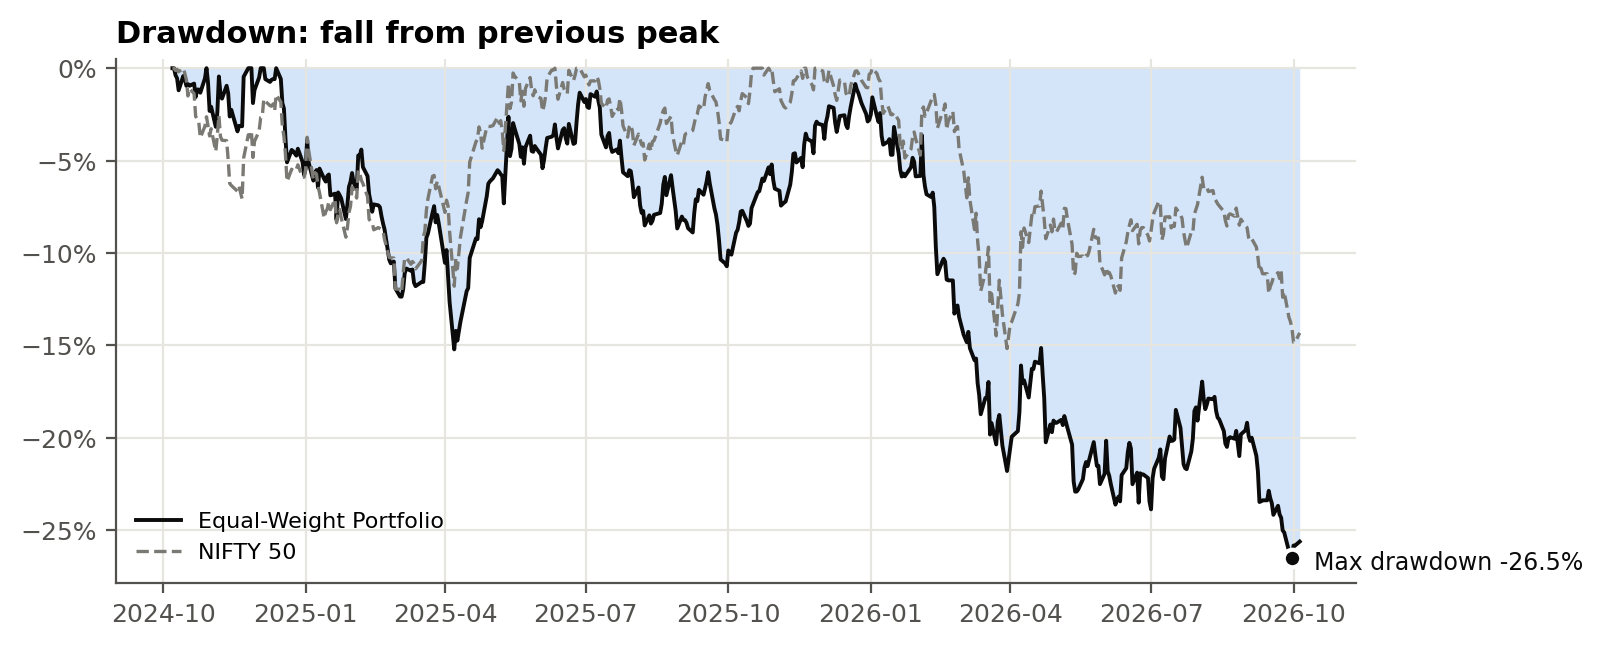

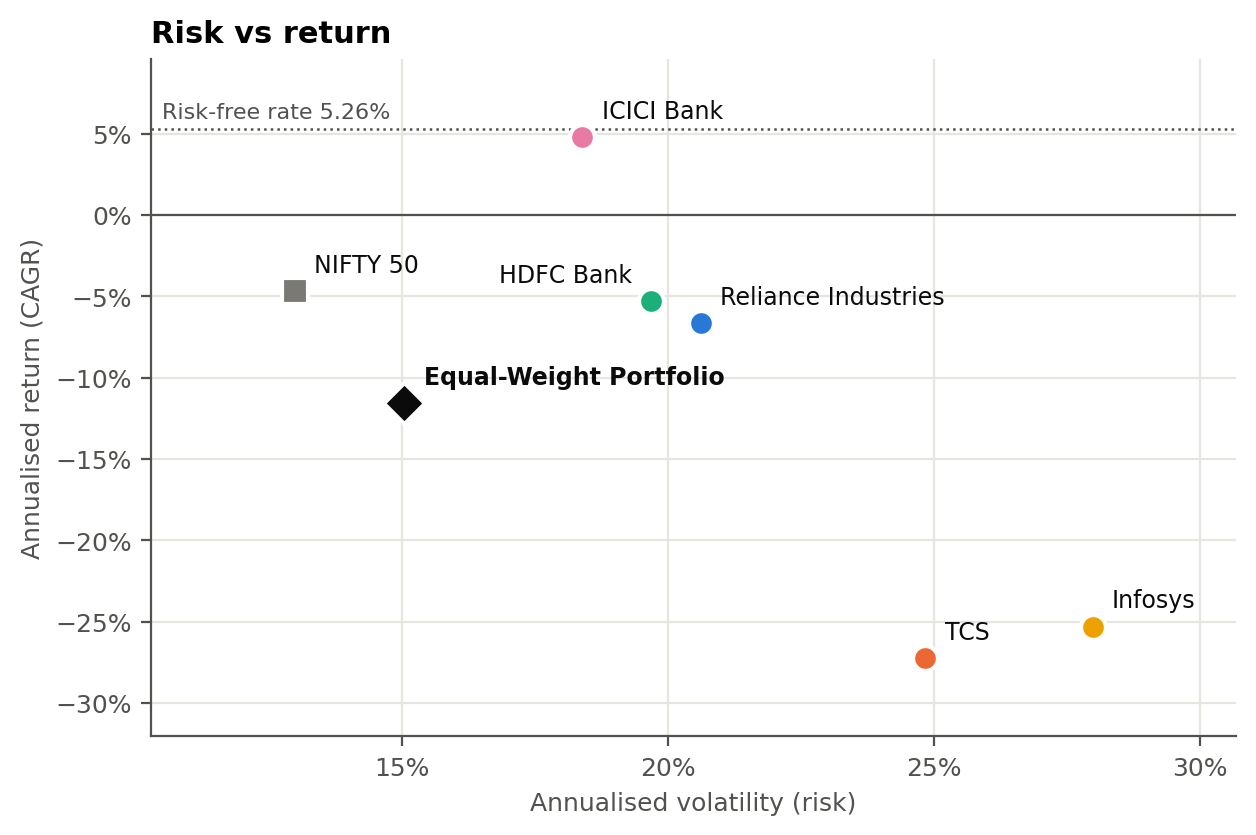

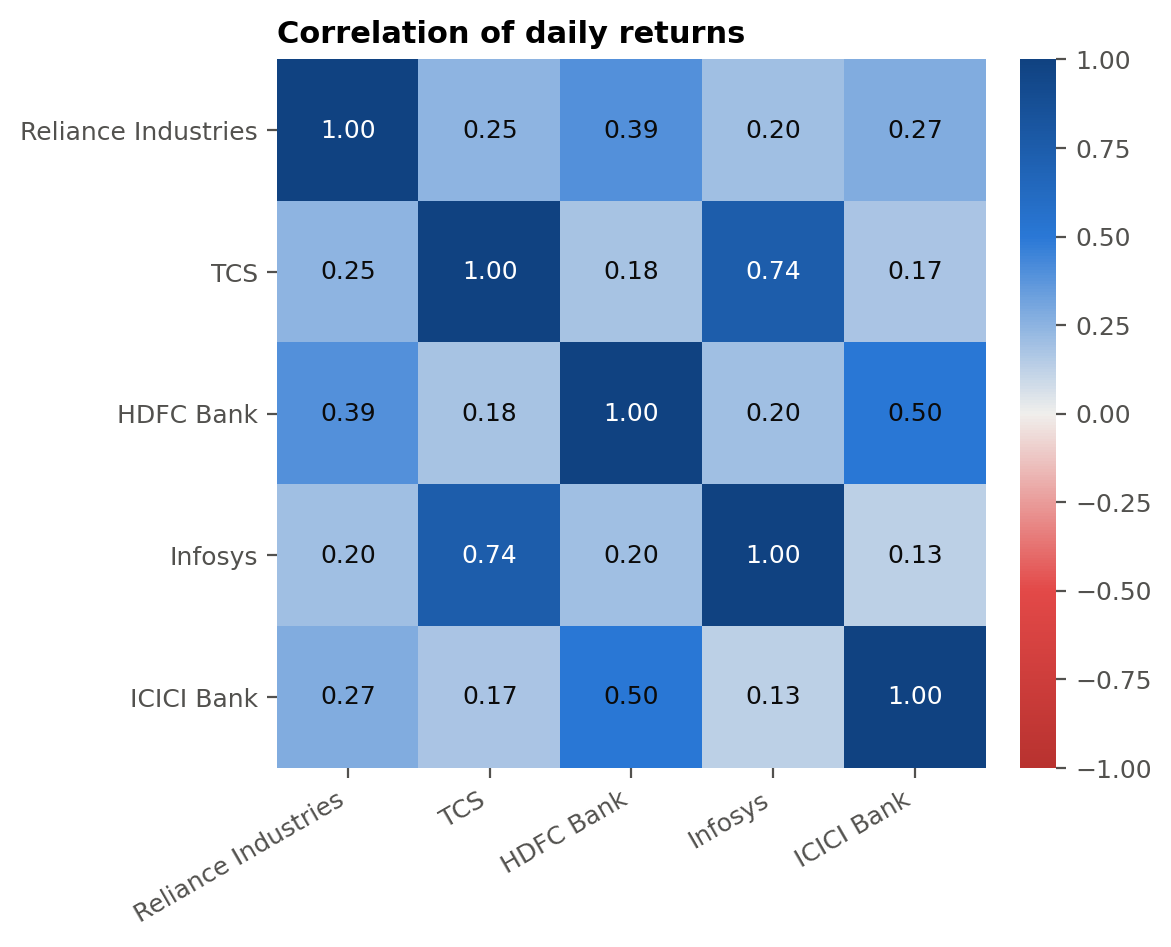

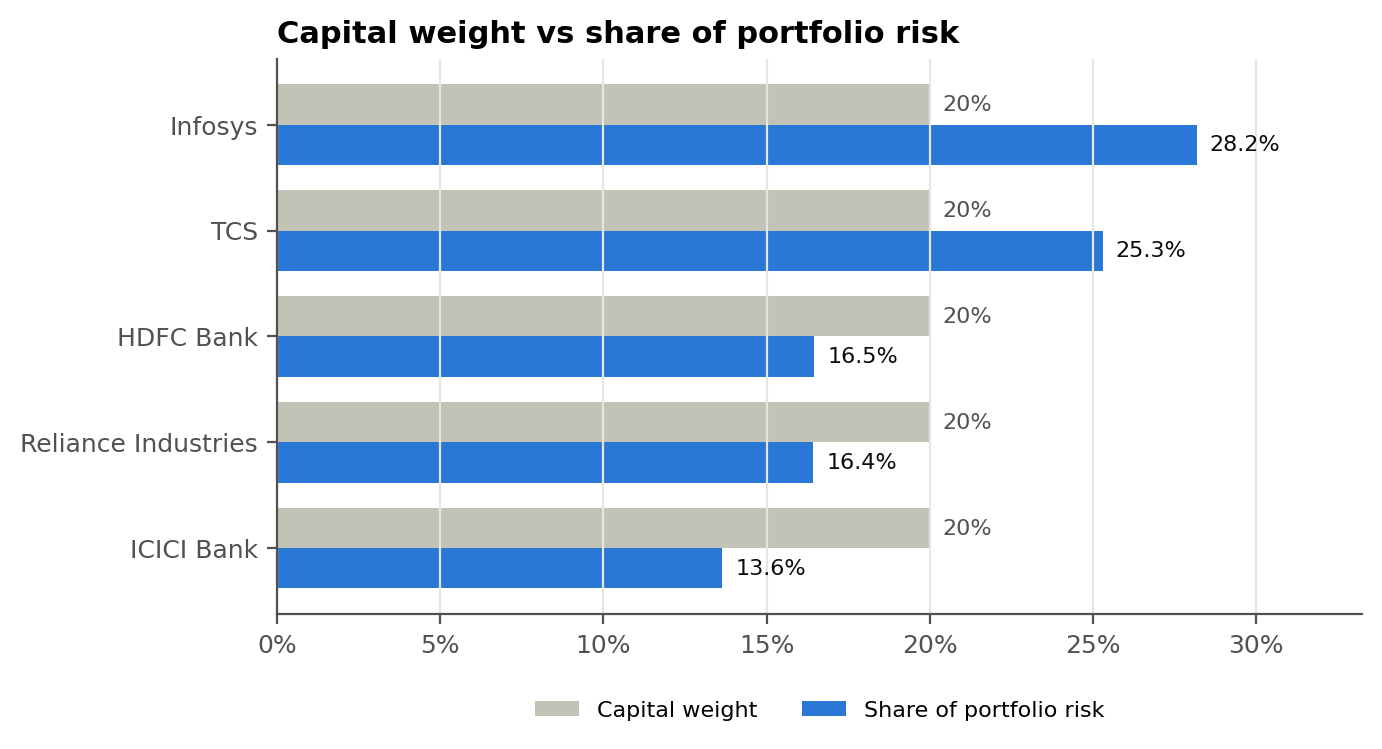

In [11]:
res = analytics.run_analysis(raw)
os.makedirs(config.CHART_DIR, exist_ok=True)
paths = charts.make_all_charts(res)
for p in paths.values():
    display(Image(filename=p))

### Consistency check

The step-by-step numbers above should match the project code exactly. If any assertion fails, the two disagree and the report should not be trusted until the difference is explained.

In [12]:
s = res["summary"]
assert np.allclose(s["Cumulative return"], cumulative[s.index])
assert np.allclose(s["Annualised return (CAGR)"], cagr[s.index])
assert np.allclose(s["Annualised volatility"], volatility[s.index])
assert np.allclose(s["Sharpe ratio"], sharpe[s.index])
assert np.allclose(s["Max drawdown"], max_dd[s.index])
assert np.isclose(res["diversification"]["portfolio_vol"], port_vol)
assert np.allclose(res["risk_contribution"]["Share of portfolio risk"], risk_contrib["Share of risk"])
print("All notebook calculations match analytics.py")

All notebook calculations match analytics.py


## 12. Key Findings

The findings below are generated from the numbers, so their wording changes with the data (for example "gained" versus "lost").

In [13]:
from insights import build_findings, business_interpretation, limitations

for i, (title, text) in enumerate(build_findings(res), 1):
    print(f"{i}. {title}\n   {text}\n")

print("BUSINESS INTERPRETATION\n")
for p in business_interpretation(res):
    print("-", p, "\n")

1. Performance
   Between 7 Oct 2024 and 5 Oct 2026 (500 trading days) the equal-weight portfolio lost 21.6% in total, an annualised return (CAGR) of -11.6%. Over the same days the NIFTY 50 returned -9.0%, so the portfolio underperformed the index by 12.6 percentage points.

2. Risk-adjusted return
   Annualised volatility was 15.0% and the Sharpe Ratio was -1.08 using a 5.26% risk-free rate. A negative Sharpe Ratio means the portfolio earned less than a risk-free Treasury Bill over this period. The NIFTY 50's Sharpe Ratio was -0.70. When both ratios are negative, ranking them is not meaningful, because a negative ratio looks less bad simply when volatility is higher; compare total return and drawdown instead.

3. Stock comparison
   ICICI Bank had the highest annualised return (4.8%) and TCS the lowest (-27.2%). Infosys was the most volatile stock (28.0%) and ICICI Bank the least (18.4%). ICICI Bank also had the best Sharpe Ratio (0.07).

4. Diversification benefit
   If the five stoc

## 13. Conclusion

In [14]:
from insights import conclusion
print(conclusion(res))
print("\nLIMITATIONS")
for x in limitations():
    print("-", x)

Over 7 Oct 2024 to 5 Oct 2026 the equal-weight portfolio of five NSE large caps lost 21.6% (-11.6% a year) with 15.0% annualised volatility, a Sharpe Ratio of -1.08 and a worst drawdown of 26.5%. The NIFTY 50 returned -9.0% with a Sharpe Ratio of -0.70. Holding five stocks cut volatility by 32.6% compared with holding perfectly correlated assets, but sector overlap and unequal risk contributions show that an equal-weight split is a starting point rather than a balanced portfolio. These results describe one historical period and are not a forecast.

LIMITATIONS
- Past returns, volatility and correlations describe one specific period and do not predict future results. Correlations in particular tend to rise during market stress, when diversification is needed most.
- Two years is a short window; it covers only the market conditions that happened to occur in it, so metrics can change materially with a different start or end date.
- Five large-cap stocks from three sectors are not a divers

**Limitations in short:** two years of history describe one market environment and do not predict the future; correlations rise in stress; five stocks across three sectors is a concentrated portfolio; costs and taxes are ignored; volatility and the Sharpe Ratio treat upside and downside alike; one T-Bill yield stands in for the risk-free rate across the whole period.